In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split

# Importing the Dataset 

In [9]:
df = pd.read_csv('cardekho_data.csv')

In [10]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Data Analysis (EDA , DE , DM , DC ,DV)

In [12]:
df.shape

(301, 9)

In [16]:
print("Fuel",df.Fuel_Type.unique())
print("Seller_Type",df.Seller_Type.unique())
print("Transmission",df.Transmission.unique())
print("Owner",df.Owner.unique())

Fuel ['Petrol' 'Diesel' 'CNG']
Seller_Type ['Dealer' 'Individual']
Transmission ['Manual' 'Automatic']
Owner [0 1 3]


In [17]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [18]:
df['Current Year'] = 2025

In [20]:
# How old the car is
df['No. of Years'] = df['Current Year']-df['Year']

In [21]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Current Year,No. of Years
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2025,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2025,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2025,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2025,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2025,11


In [23]:
df.drop(columns={'Current Year','Car_Name','Year'},axis = 1 , inplace = True )

In [25]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,No. of Years
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


# changing the categorical data into numerical data - One hot Encoder (get_dummies)

In [32]:
df =pd.get_dummies(df,dtype=int)

In [33]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,No. of Years,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,3.35,5.59,27000,0,11,0,0,1,1,0,0,1
1,4.75,9.54,43000,0,12,0,1,0,1,0,0,1
2,7.25,9.85,6900,0,8,0,0,1,1,0,0,1
3,2.85,4.15,5200,0,14,0,0,1,1,0,0,1
4,4.60,6.87,42450,0,11,0,1,0,1,0,0,1


In [35]:
df.shape

(301, 12)

In [36]:
# we can remove one column bcoz if we know two then it is very obvious to jugde the 3rd one 
df.drop(columns={'Fuel_Type_CNG','Seller_Type_Dealer','Transmission_Automatic'},axis = 1,inplace = True)

In [37]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,No. of Years,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,0,1,0,1
1,4.75,9.54,43000,0,12,1,0,0,1
2,7.25,9.85,6900,0,8,0,1,0,1
3,2.85,4.15,5200,0,14,0,1,0,1
4,4.60,6.87,42450,0,11,1,0,0,1


In [38]:
df.shape

(301, 9)

In [39]:
df.corr()

,Selling_Price,Present_Price,Kms_Driven,Owner,No. of Years,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Selling_Price,1.000000,0.878983,0.029187,-0.088344,-0.236141,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,0.878983,1.000000,0.203647,0.008057,0.047584,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,0.029187,0.203647,1.000000,0.089216,0.524342,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.088344,0.008057,0.089216,1.000000,0.182104,-0.053469,0.055687,0.124269,-0.050316
No. of Years,-0.236141,0.047584,0.524342,0.182104,1.000000,-0.064315,0.059959,0.039896,-0.000394
Fuel_Type_Diesel,0.552339,0.473306,0.172515,-0.053469,-0.064315,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.540571,-0.465244,-0.172874,0.055687,0.059959,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.550724,-0.512030,-0.101419,0.124269,0.039896,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.367128,-0.348715,-0.162510,-0.050316,-0.000394,-0.098643,0.091013,0.063240,1.000000


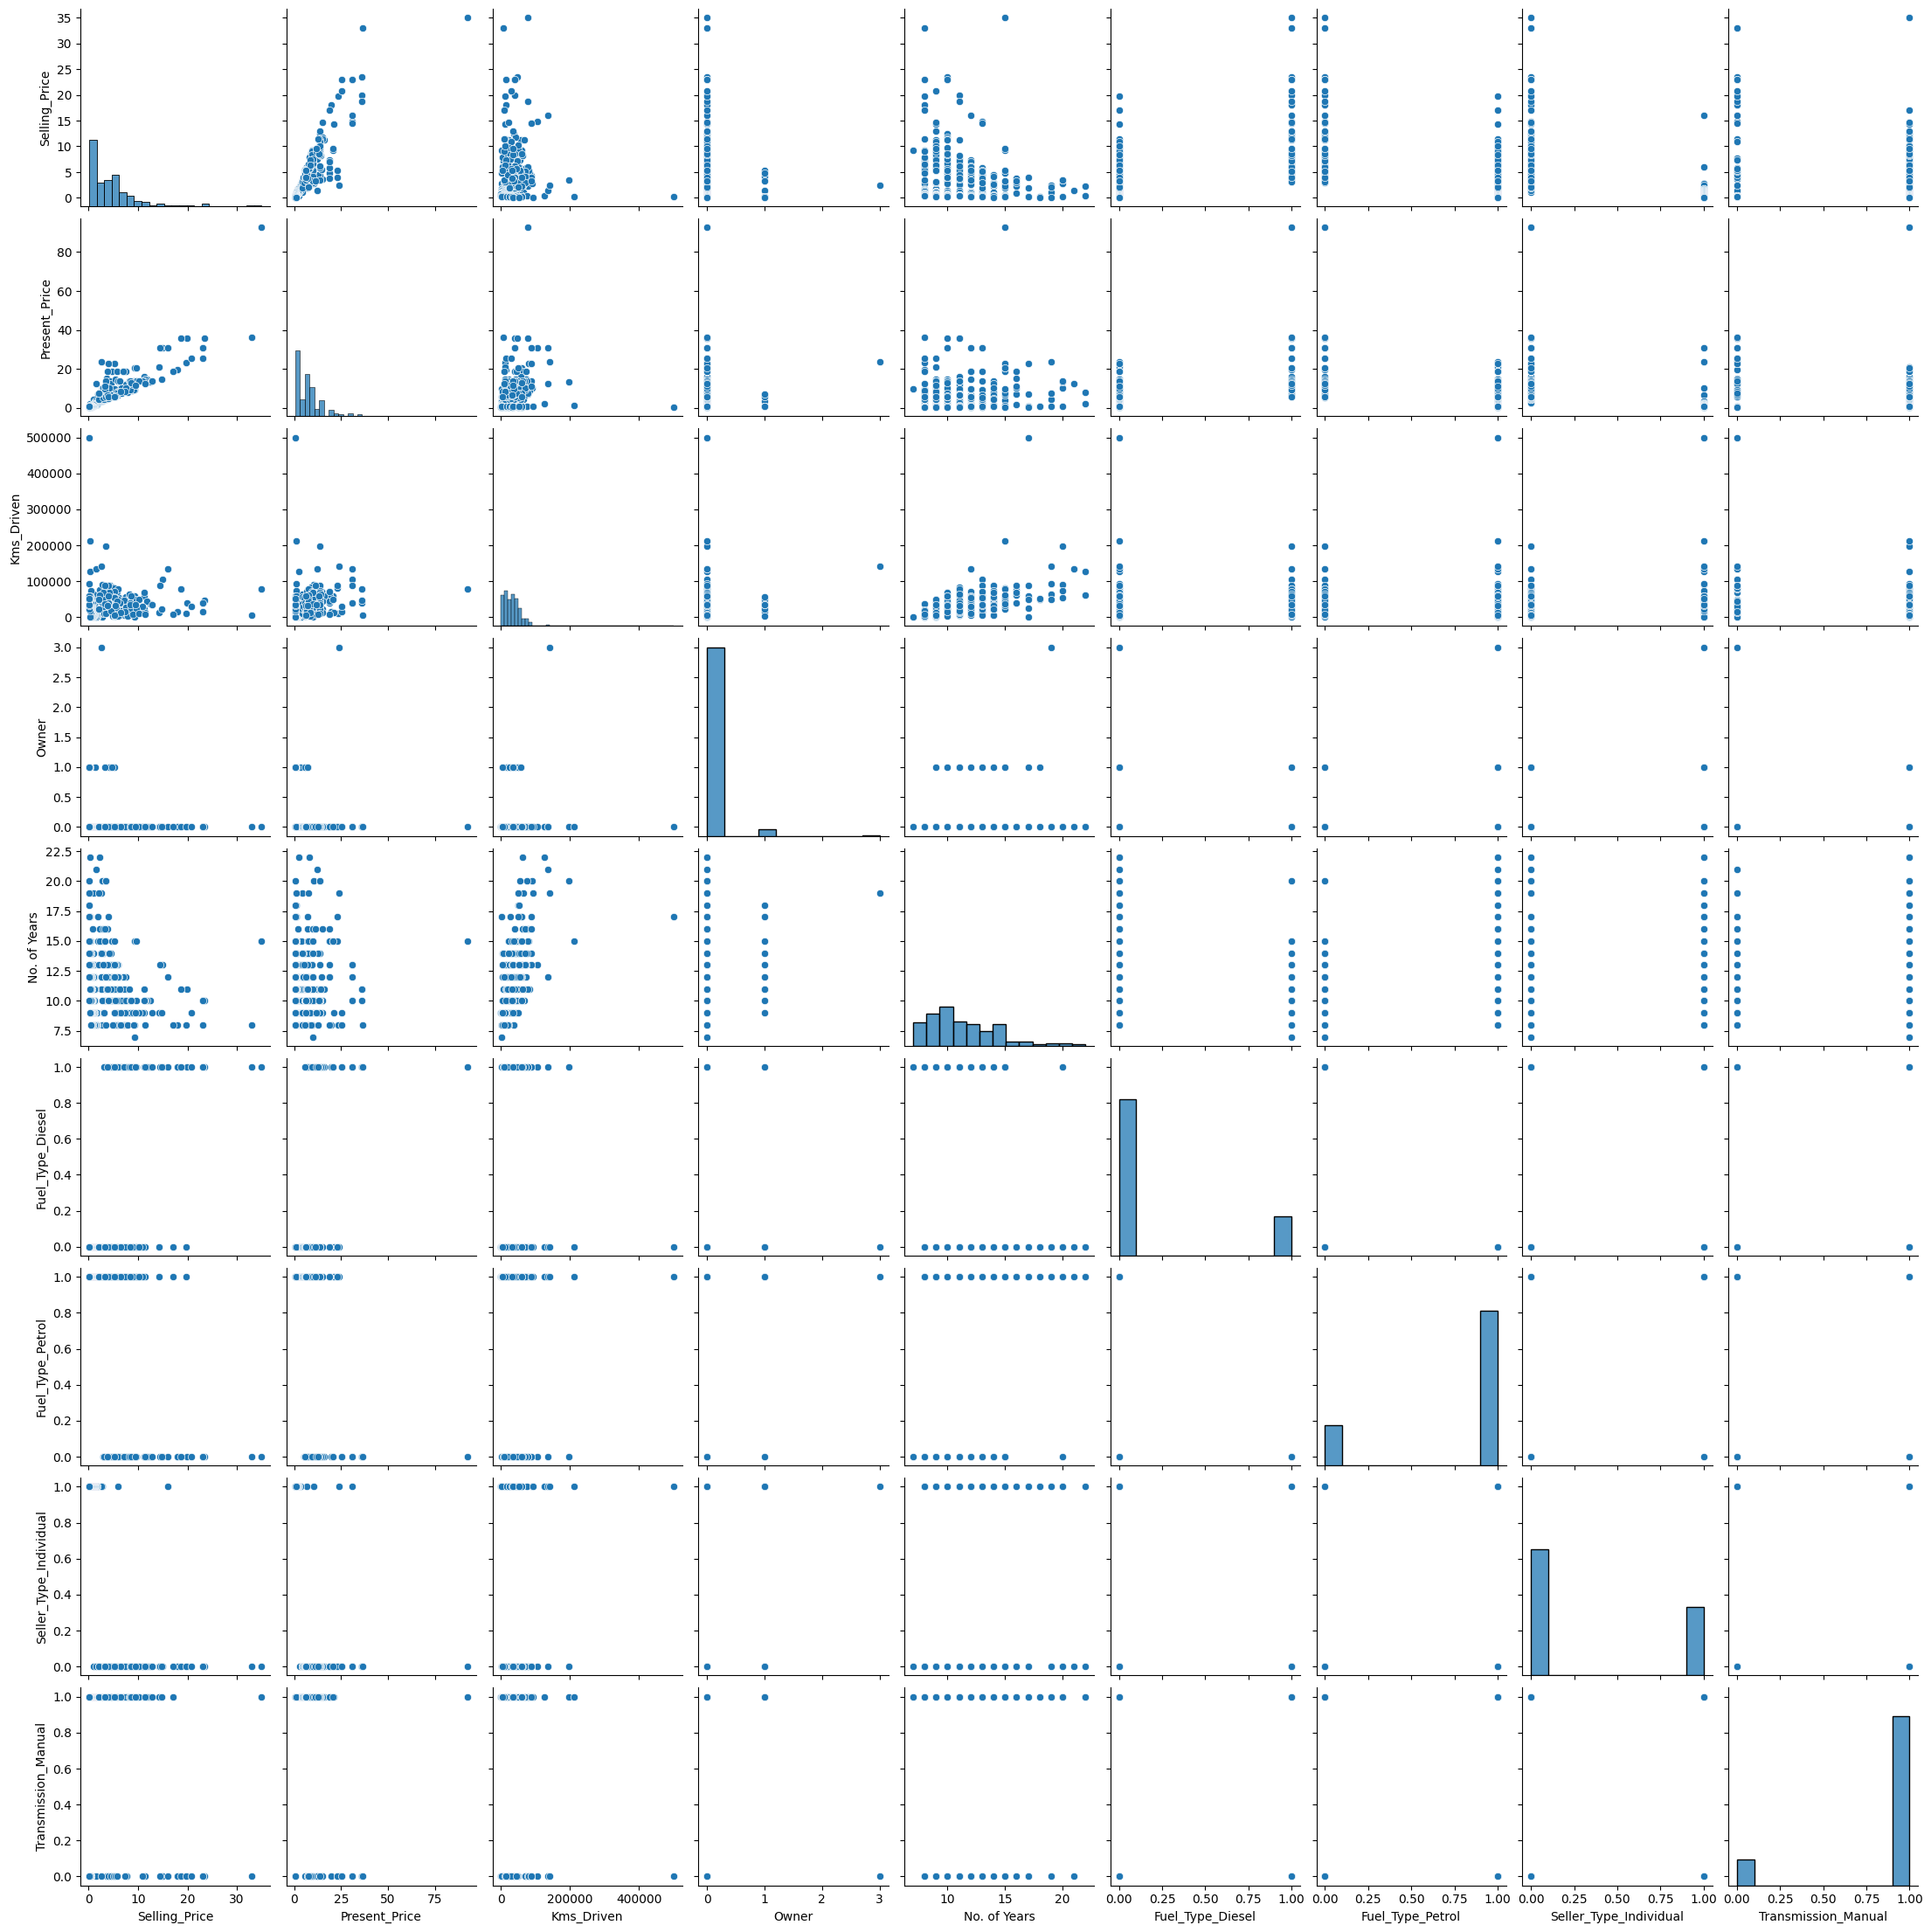

In [40]:
# it will going to create a plot b/w diff features 
sns.pairplot(df)


<Axes: >

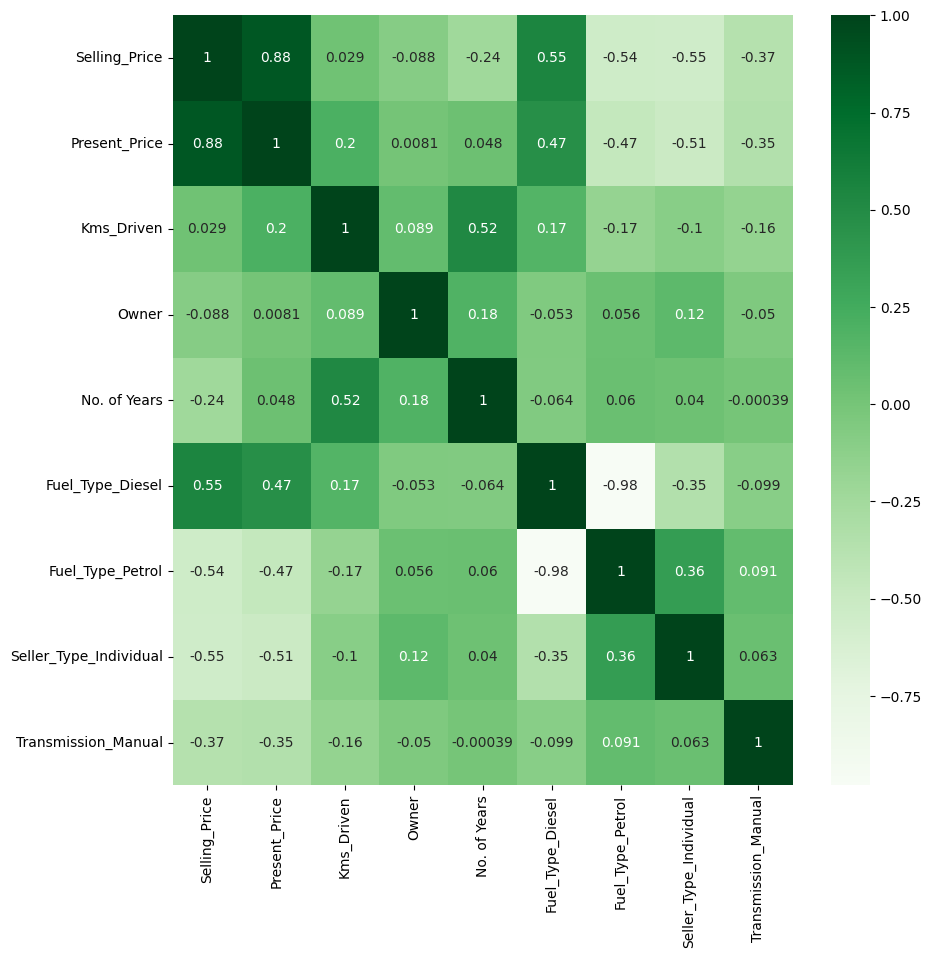

In [41]:
plt.figure(figsize= (10,10))
sns.heatmap(df.corr(),annot = True, cmap='Greens')

# Spliting the features

In [43]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,No. of Years,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,0,1,0,1
1,4.75,9.54,43000,0,12,1,0,0,1
2,7.25,9.85,6900,0,8,0,1,0,1
3,2.85,4.15,5200,0,14,0,1,0,1
4,4.60,6.87,42450,0,11,1,0,0,1


In [46]:
# X = np.array(df.drop('Selling_Price'))
X = np.array(df.iloc[:,1:])
Y = np.array(df.iloc[:,0])

In [49]:
Y

array([ 3.35,  4.75,  7.25,  2.85,  4.6 ,  9.25,  6.75,  6.5 ,  8.75,
        7.45,  2.85,  6.85,  7.5 ,  6.1 ,  2.25,  7.75,  7.25,  7.75,
        3.25,  2.65,  2.85,  4.9 ,  4.4 ,  2.5 ,  2.9 ,  3.  ,  4.15,
        6.  ,  1.95,  7.45,  3.1 ,  2.35,  4.95,  6.  ,  5.5 ,  2.95,
        4.65,  0.35,  3.  ,  2.25,  5.85,  2.55,  1.95,  5.5 ,  1.25,
        7.5 ,  2.65,  1.05,  5.8 ,  7.75, 14.9 , 23.  , 18.  , 16.  ,
        2.75,  3.6 ,  4.5 ,  4.75,  4.1 , 19.99,  6.95,  4.5 , 18.75,
       23.5 , 33.  ,  4.75, 19.75,  9.25,  4.35, 14.25,  3.95,  4.5 ,
        7.45,  2.65,  4.9 ,  3.95,  5.5 ,  1.5 ,  5.25, 14.5 , 14.73,
        4.75, 23.  , 12.5 ,  3.49,  2.5 , 35.  ,  5.9 ,  3.45,  4.75,
        3.8 , 11.25,  3.51, 23.  ,  4.  ,  5.85, 20.75, 17.  ,  7.05,
        9.65,  1.75,  1.7 ,  1.65,  1.45,  1.35,  1.35,  1.35,  1.25,
        1.2 ,  1.2 ,  1.2 ,  1.15,  1.15,  1.15,  1.15,  1.11,  1.1 ,
        1.1 ,  1.1 ,  1.05,  1.05,  1.05,  1.05,  1.  ,  0.95,  0.9 ,
        0.9 ,  0.75,

# Feature Selection(Feature Importance)

In [50]:
# Tells the important features 
from sklearn.ensemble import ExtraTreesRegressor

In [52]:
model = ExtraTreesRegressor()
feat_imp = model.fit(X,Y)

In [54]:
feat_imp.feature_importances_

array([0.38717162, 0.03796421, 0.000883  , 0.07841856, 0.23581027,
       0.00967179, 0.13097552, 0.11910503])

In [56]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

<Axes: >

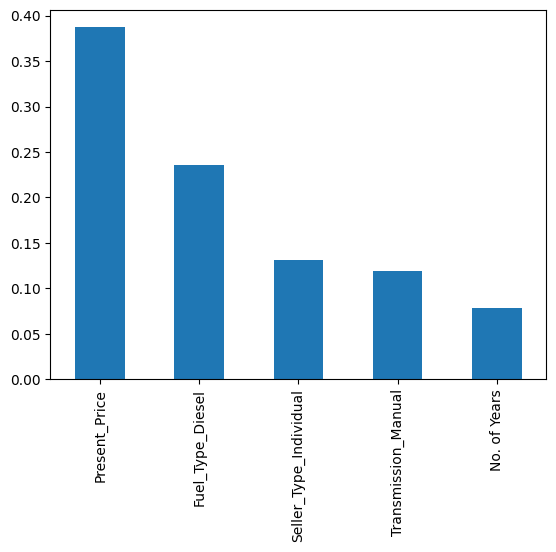

In [61]:
imp = pd.Series(feat_imp.feature_importances_, index=X.columns)
imp.nlargest(5).plot(kind='bar')

# Split the Data 

In [62]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# Model Selection

In [65]:
regressor = RandomForestRegressor()

# Hyper Parameter Tuning

In [ ]:
# find out the best parameters 

In [89]:
n_estimators= [int(i) for i in np.linspace(start =100 ,stop =3200 , num =12)]
max_features=(1.0 ,'sqrt')
max_depth = [int(i) for i in np.linspace(start =5,stop =90 , num =10)]
min_samples_split = [2,5,10,15,100]
min_samples_leaf = [1,2,5,10] 

In [90]:
random_grid = {'n_estimators':n_estimators ,'max_features':max_features ,'max_depth':max_depth ,'min_samples_split':min_samples_split , 'min_samples_leaf':min_samples_leaf}

In [69]:
from sklearn.model_selection import RandomizedSearchCV

In [91]:
rf_regressor = RandomizedSearchCV(estimator = regressor,param_distributions=random_grid,scoring='neg_mean_squared_error',cv=5
                                 ,random_state=42,n_jobs=1)

# Fitting the Model 

In [92]:
rf_regressor.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 14, 23, 33, 42, 52, 61,
                                                      71, 80, 90],
                                        'max_features': (1.0, 'sqrt'),
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 381, 663, 945,
                                                         1227, 1509, 1790, 2072,
                                                         2354, 2636, 2918,
                                                         3200]},
                   random_state=42, scoring='neg_mean_squared_error')

In [93]:
# tells which are the best parameters combination that will give high accuracy -- best parametric values 
rf_regressor.best_params_ 

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 1.0,
 'max_depth': 71}

In [94]:
y_pred = rf_regressor.predict(x_test)

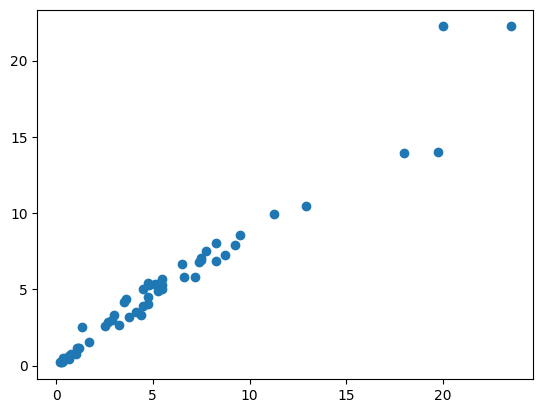

In [95]:
plt.scatter(y_test , y_pred)

In [96]:
finaldf = pd.DataFrame({'Actual':y_test ,'Predicted':y_pred})

In [97]:
finaldf

,Actual,Predicted
223,8.25,6.846423
150,0.50,0.510471
226,5.25,4.881533
296,9.50,8.591829
52,18.00,13.955972
...,...,...
137,0.65,0.413576
227,2.55,2.625217
26,4.15,3.522810
106,1.35,2.548296


<Axes: >

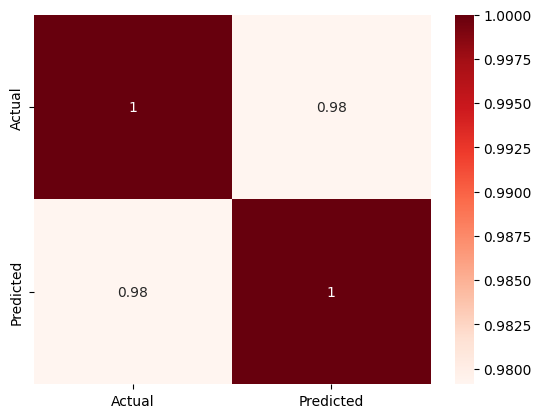

In [98]:
sns.heatmap(finaldf.corr(),annot =True,cmap ='Reds')

# Performance

In [87]:
from sklearn.metrics import r2_score

In [99]:
r2_score(y_pred ,y_test)

0.9350544537541967